### APS1070 Project 3 - Part 1, Git Practice

**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the APS1070 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself. Students suspected of plagiarism on a project, midterm or exam will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Please fill out the following:


*   Your **name**: Juliana Gomez
*   Your **student number**: 1005666085



## Part 1: Getting started with GitHub [1.5 Marks + 2 Mark Git Submission]


For the first four parts (Part 1-4) of this project, we will work on a [population of countries dataset](https://ourworldindata.org/grapher/population) which reports the population of over 200 countries worldwide from 10000 BCE to 2023. Download the dataset in .csv format using the provided code below. Using the Pandas package, create a population dataframe with only the countries provided in [this GitHub list](https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt) (237 countries - you should remove all other entities) as rows and years from 1901 to 2023 (123 years) as columns. Then, remove all the countries that have at least missing or invalid value over the years.

In [1]:
import pandas as pd
import requests, io

headers = {"User-Agent": "Mozilla/5.0"}
raw_data = pd.read_csv(
    filepath_or_buffer=io.StringIO(requests.get(
        'https://ourworldindata.org/grapher/population.csv?v=1&csvType=full&useColumnShortNames=true',
        headers=headers).text),
    index_col=False)

countries_list_url = "https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt"

In [2]:
#Print table of raw data to check columns and headers
raw_data.head()

,entity,code,year,population_historical
0,Afghanistan,AFG,-10000,14737
1,Afghanistan,AFG,-9000,20405
2,Afghanistan,AFG,-8000,28253
3,Afghanistan,AFG,-7000,39120
4,Afghanistan,AFG,-6000,54166


In [3]:
raw_data.shape #Check original size of the data

(58824, 4)

In [4]:
#Using the Pandas package, create a population dataframe with only the countries provided in this GitHub list (237 countries -
#you should remove all other entities) as rows and years from 1901 to 2023 (123 years) as columns.

#Save the list from the countries that will be included
countries_list = pd.read_csv(countries_list_url, header=None)[0].tolist()
#Print the first 10, should start with Afghanistan
countries_list[:10]


['Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia']

In [5]:
#Filter the dataset to include just the list countries_list
filtered_df = raw_data[raw_data['entity'].isin(countries_list)] #Notice country name is labeled as "entity"
filtered_df.shape

(54240, 4)

In [6]:
# this GitHub list (237 countries - you should remove all other entities) as rows and years from 1901 to 2023 (123 years) as columns.
# Then, remove all the countries that have at least missing or invalid value over the years.
short_df = filtered_df[(filtered_df['year'] >= 1901) & (filtered_df['year'] <= 2023)]
short_df.shape


(27253, 4)

In [7]:
# Reshape to wide format so years appear as columns
df_pivot = short_df.pivot(index='entity', columns='year', values='population_historical')
df_pivot.shape

(237, 123)

In [8]:
# Flag invalid values (zero or negative) as missing too
df_pivot = df_pivot.where(df_pivot > 0, other=pd.NA) #Please note this part was suggested by Claude when I was validating the code, to take into accunt not just missing values but also invalid values

#Remove missing values
df_clean = df_pivot.dropna(axis=0, how='any') #The 'any' is there to remove any country that has at least one invalid/missing value in any of the year columns
df_clean.shape

(196, 123)

1. Write a function to do the following: **[0.5]**
    * Takes the dataframe, and your list of countries/regions as inputs (Afghanistan, Albania, Algeria, ...)
    * Plots time-series for the input list (it is best to plot each country in a separate graph (subplot), so you can easily compare them.)
    
2. Apply `StandardScalar` to the data. Each year should have a `mean` of zero and a `StD` of 1. **[0.25]**
3. Pick two countries whose names are closest to your first name using string edit distance.
Hint: you can use `Levenshtein.distance()` from the python-Levenshtein package. You may find [this link](https://www.geeksforgeeks.org/python/introduction-to-python-levenshtein-module/) helpful.
4. Run the function in `step 1` on both the original as well as the standardized dataset for the two countries you picked in `step 3` plus `Japan`, `Bosnia and Herzegovina`, `Latvia`, and `United Arab Emirates`. (If you have already selected one of these countries, go down the list and pick the next one you haven't selected) **[0.25]**
5. Discuss the trends in the standardized time-series for all these countries. What does it mean if the curve goes up or down? What does the sign of values indicate? **[0.5]**

In [9]:
#Part 1.1 Function that takes the df, and a list of countries as input to plot a time-series for the input list, plotting each country in a separate graph or subplot

import matplotlib.pyplot as plt
import math

def plot_time_series(df, countries):
    #Start by allocating space for the plot:
    n = len(countries)
    ncols = 2 if n > 1 else 1
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols)
    axes = axes.flatten() if n > 1 else [axes]  # handle single-country case, this was added by Claude to include a case of just one country

    #Find countries in df
    for j, i in enumerate(countries):
        if i in df.index:
            years = df.columns
            population = df.loc[i]
            axes[j].plot(years, population)
            axes[j].set_title(i)
            axes[j].set_xlabel("Year")
            axes[j].set_ylabel("Population")
        else:
            print(f"Warning: '{i}' not found in dataframe, skipping.")

    plt.tight_layout()
    plt.show()


In [10]:
#Part 1.2. Apply StandardScalar to the data. Each year should have a mean of zero and a StD of 1.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_clean)

# Scaled dataframe with the same countries/years labels
df_scaled = pd.DataFrame(scaled_array, index=df_clean.index, columns=df_clean.columns)

In [11]:
#Part 1.2 verify that it actually worked
print(df_scaled.mean().round(2))       # should show close to 0.0 for every year
print(df_scaled.std(ddof=0).round(2))  # should show close to 1.0 for every year

year
1901   -0.0
1902   -0.0
1903   -0.0
1904    0.0
1905   -0.0
       ... 
2019   -0.0
2020    0.0
2021   -0.0
2022    0.0
2023    0.0
Length: 123, dtype: float64
year
1901    1.0
1902    1.0
1903    1.0
1904    1.0
1905    1.0
       ... 
2019    1.0
2020    1.0
2021    1.0
2022    1.0
2023    1.0
Length: 123, dtype: float64


In [12]:
#Levenshtein installation if needed.
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.8 MB/s eta 0:00:00


In [13]:
#Part 1.3 Pick two countries whose names are closest to your first name using string edit distance.
#Hint: you can use Levenshtein.distance() from the python-Levenshtein package. You may find this link helpful.

import Levenshtein

distances = {}

for i in df_clean.index:
    input1 = "juliana"
    input2 = i
    dist_calc = Levenshtein.distance(input1, input2)
    distances[i] = dist_calc

distances_series = pd.Series(distances)
sorted_distances = distances_series.sort_values()


# The closest countries
closest_two = sorted_distances.head(2)
print(closest_two)


Guyana     3
Albania    4
dtype: int64


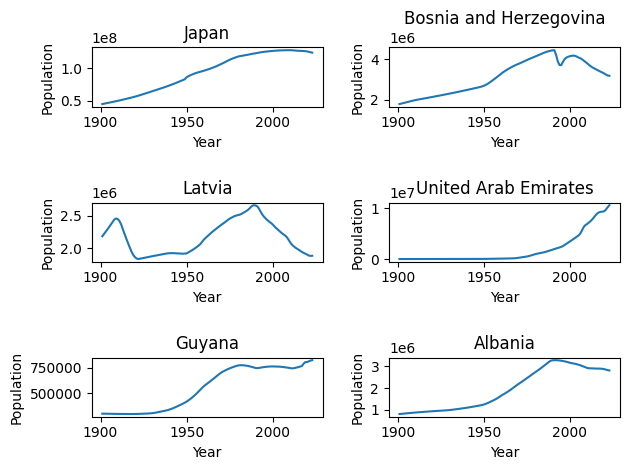

In [14]:
#Part 1.4.

#Run the function in step 1 on both the original as well as the standardized dataset for the two countries you picked in step 3 plus Japan, Bosnia and Herzegovina, Latvia, and United Arab Emirates.
 #(If you have already selected one of these countries, go down the list and pick the next one you haven't selected) [0.25]

Countries_add=["Japan", "Bosnia and Herzegovina", "Latvia", "United Arab Emirates"]+closest_two.index.tolist()

#Run on the original (i.e. not scaled dataset)
plot_time_series(df_clean, Countries_add)



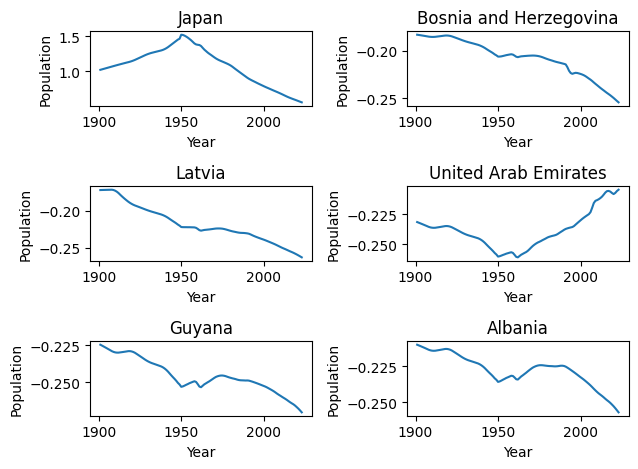

In [15]:
#Run on the scaled dataset
plot_time_series(df_scaled, Countries_add)

**Part 1.5** Discuss the trends in the standardized time-series for all these countries. What does it mean if the curve goes up or down? What does the sign of values indicate? [0.5]

For the raw unstandardized values, the trends represent the total population in each country, and what we can see is in general, all the countries I plotted (Japan, Bosnia and Herzegovina, Latvia, United Arab Emirates, Guyana and Albania) all seemed to have a period in which their total population count increased. Between 1980s-2000s, the overall population count for Japan, Bosnia and Herzegovina, Guyana and Albania, seemed to either plateau or slightly decrease. A notable exception was United Arab Emirates, whose population has been exponentially increasing since 1960. Also, Latvia, seemed to have a fluctuating population, showing an intial peak around 1910s, and then another one 1990. The curves going up represent an increase in the total population of the country, while the curves going down represent a decrease of the total population for that country over time. In this case, we do not have changes in sign since we count total population at each time point per year.

For the standardized time-series, we are looking at a different metric, each point should be evaluated as how does the total population for that country compare to the mean population of all the 237 countries taken into account. Therefore, an increasing curve could represent either a) the population of that country increased while the mean population of other countries stayed the same or decreased, or b) the population for that country stayed the same but the mean population for other countries decreased. A decreasing trend also could be because of a decrease in total population, or an increased mean population of other countries. The closer the values are to 0 then the closer the population is to the mean of the other countries. A negative value represents the population is below the average value across all countries, and a positive populations is above the average value across all countries.

Looking at the standardized time-series, shows how Japan is the only country that has had population above the average population across all other countries, this peaked in 1950 and has been decreasing over time. Bosnia, Latvia, Guyana, and Albania, all show populations that are below the average population and continue to decrease (i.e. become more negative) suggesting their population continues decrese compared to other countries. United Arab Emirates, despite also having a population that is lower than other countries, has continuously increased over time since 1950s relative to the population in other countries.

